In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
# Load the dataset
df = pd.read_csv('../data/application_train.csv')

# Basic shape
print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

Rows    : 307511
Columns : 122


In [3]:
# See first 5 rows
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,...,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.00,406597.50,24700.50,351000.00,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.02,-9461,-637,-3648.00,-2120,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,1.00
1,100003,0,Cash loans,F,N,N,0,270000.00,1293502.50,35698.50,1129500.00,Family,State servant,Higher education,Married,House / apartment,0.00,-16765,-1188,-1186.00,-291,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
2,100004,0,Revolving loans,M,Y,Y,0,67500.00,135000.00,6750.00,135000.00,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.01,-19046,-225,-4260.00,-2531,26.00,1,1,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
3,100006,0,Cash loans,F,N,Y,0,135000.00,312682.50,29686.50,297000.00,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.01,-19005,-3039,-9833.00,-2437,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.00,513000.00,21865.50,513000.00,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.03,-19932,-3038,-4311.00,-3458,NaN,1,1,0,...,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00


In [4]:
# How many defaulted vs repaid?
target_counts = df['TARGET'].value_counts()
default_rate  = df['TARGET'].mean() * 100

print("0 = Repaid   :", target_counts[0])
print("1 = Defaulted:", target_counts[1])
print(f"\nDefault Rate : {default_rate:.2f}%")

0 = Repaid   : 282686
1 = Defaulted: 24825

Default Rate : 8.07%


In [5]:
# Which columns have the most missing data?
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %'    : missing_pct
})

print(missing_df.head(20))

                          Missing Count  Missing %
COMMONAREA_MEDI                  214865      69.87
COMMONAREA_MODE                  214865      69.87
COMMONAREA_AVG                   214865      69.87
NONLIVINGAPARTMENTS_MODE         213514      69.43
NONLIVINGAPARTMENTS_MEDI         213514      69.43
NONLIVINGAPARTMENTS_AVG          213514      69.43
FONDKAPREMONT_MODE               210295      68.39
LIVINGAPARTMENTS_AVG             210199      68.35
LIVINGAPARTMENTS_MEDI            210199      68.35
LIVINGAPARTMENTS_MODE            210199      68.35
FLOORSMIN_MEDI                   208642      67.85
FLOORSMIN_MODE                   208642      67.85
FLOORSMIN_AVG                    208642      67.85
YEARS_BUILD_MODE                 204488      66.50
YEARS_BUILD_MEDI                 204488      66.50
YEARS_BUILD_AVG                  204488      66.50
OWN_CAR_AGE                      202929      65.99
LANDAREA_AVG                     182590      59.38
LANDAREA_MEDI                  

C:\Users\savji\AppData\Local\Temp\ipykernel_21916\1495774259.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='TARGET', data=df,


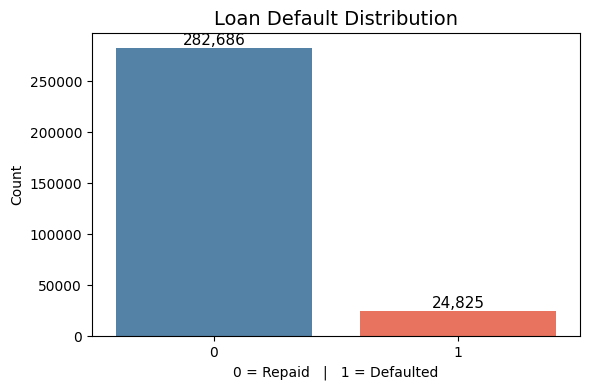

In [6]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='TARGET', data=df,
                   palette=['steelblue', 'tomato'])

# Add count labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.title('Loan Default Distribution', fontsize=14)
plt.xlabel('0 = Repaid   |   1 = Defaulted')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../data/target_distribution.png')
plt.show()